# Regression

In [111]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor,plot_tree
import math

In [85]:
df=pd.read_csv('Book1.csv')

In [86]:
df

,IQ,CGPA,Salary
0,90,8,3
1,100,7,4
2,110,6,8
3,120,9,6
4,80,5,3


In [87]:
df['Pred1']=np.average(df['Salary'])
df['Pred1']

0    4.8
1    4.8
2    4.8
3    4.8
4    4.8
Name: Pred1, dtype: float64

In [88]:
df['Res1']=df['Salary']-df['Pred1']

In [89]:
X=df[['IQ','CGPA']]
y=df['Res1']

In [90]:
model_1=DecisionTreeRegressor()
model_1.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.5, 0.8333333333333334, 'IQ <= 105.0\nsquared_error = 3.76\nsamples = 5\nvalue = 0.0'),
 Text(0.25, 0.5, 'IQ <= 95.0\nsquared_error = 0.222\nsamples = 3\nvalue = -1.467'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.0\nsamples = 2\nvalue = -1.8'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = -0.8'),
 Text(0.75, 0.5, 'CGPA <= 7.5\nsquared_error = 1.0\nsamples = 2\nvalue = 2.2'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 3.2'),
 Text(0.875, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 1.2')]

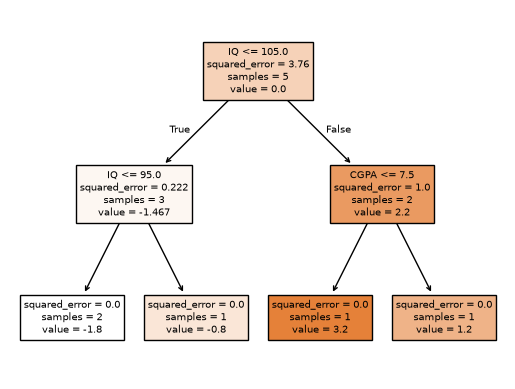

In [91]:
plot_tree(model_1,feature_names=['IQ','CGPA'], class_names=['Res1'], filled=True)


In [92]:
df['Pred2']=df['Pred1']+0.1*model_1.predict(X)

In [93]:
df

,IQ,CGPA,Salary,Pred1,Res1,Pred2
0,90,8,3,4.8,-1.8,4.62
1,100,7,4,4.8,-0.8,4.72
2,110,6,8,4.8,3.2,5.12
3,120,9,6,4.8,1.2,4.92
4,80,5,3,4.8,-1.8,4.62


In [94]:
df['Res2']=df['Salary']-df['Pred2']     # Y_pred= m1+ lr*m2

In [95]:
df

,IQ,CGPA,Salary,Pred1,Res1,Pred2,Res2
0,90,8,3,4.8,-1.8,4.62,-1.62
1,100,7,4,4.8,-0.8,4.72,-0.72
2,110,6,8,4.8,3.2,5.12,2.88
3,120,9,6,4.8,1.2,4.92,1.08
4,80,5,3,4.8,-1.8,4.62,-1.62


In [96]:
y=df['Res2']
model_2=DecisionTreeRegressor()
model_2.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.5, 0.8333333333333334, 'IQ <= 105.0\nsquared_error = 3.046\nsamples = 5\nvalue = 0.0'),
 Text(0.25, 0.5, 'IQ <= 95.0\nsquared_error = 0.18\nsamples = 3\nvalue = -1.32'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.0\nsamples = 2\nvalue = -1.62'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = -0.72'),
 Text(0.75, 0.5, 'IQ <= 115.0\nsquared_error = 0.81\nsamples = 2\nvalue = 1.98'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 2.88'),
 Text(0.875, 0.16666666666666666, 'squared_error = -0.0\nsamples = 1\nvalue = 1.08')]

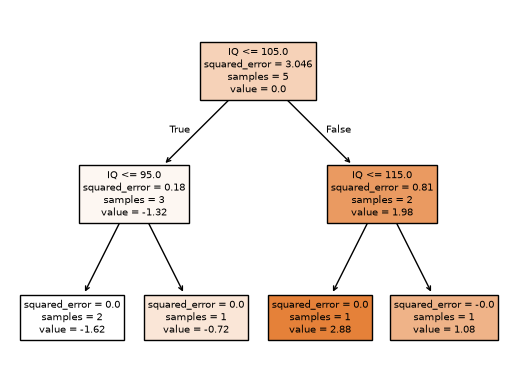

In [97]:
plot_tree(model_2,feature_names=['IQ','CGPA'], class_names=['Res2'], filled=True)


In [98]:
df['Pred3']=df['Pred1']+0.1*model_1.predict(X)+0.1*model_2.predict(X)

In [99]:
df

,IQ,CGPA,Salary,Pred1,Res1,Pred2,Res2,Pred3
0,90,8,3,4.8,-1.8,4.62,-1.62,4.458
1,100,7,4,4.8,-0.8,4.72,-0.72,4.648
2,110,6,8,4.8,3.2,5.12,2.88,5.408
3,120,9,6,4.8,1.2,4.92,1.08,5.028
4,80,5,3,4.8,-1.8,4.62,-1.62,4.458


In [100]:
df['Res3']=df['Salary']-df['Pred2']     # Y_pred= m0+ lr*m1+ lr*m2

In [101]:
df

,IQ,CGPA,Salary,Pred1,Res1,Pred2,Res2,Pred3,Res3
0,90,8,3,4.8,-1.8,4.62,-1.62,4.458,-1.62
1,100,7,4,4.8,-0.8,4.72,-0.72,4.648,-0.72
2,110,6,8,4.8,3.2,5.12,2.88,5.408,2.88
3,120,9,6,4.8,1.2,4.92,1.08,5.028,1.08
4,80,5,3,4.8,-1.8,4.62,-1.62,4.458,-1.62


In [102]:
y=df['Res3']
model_3=DecisionTreeRegressor()
model_3.fit(X,y)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.5, 0.8333333333333334, 'IQ <= 105.0\nsquared_error = 3.046\nsamples = 5\nvalue = 0.0'),
 Text(0.25, 0.5, 'IQ <= 95.0\nsquared_error = 0.18\nsamples = 3\nvalue = -1.32'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 0.0\nsamples = 2\nvalue = -1.62'),
 Text(0.375, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = -0.72'),
 Text(0.75, 0.5, 'CGPA <= 7.5\nsquared_error = 0.81\nsamples = 2\nvalue = 1.98'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = 2.88'),
 Text(0.875, 0.16666666666666666, 'squared_error = -0.0\nsamples = 1\nvalue = 1.08')]

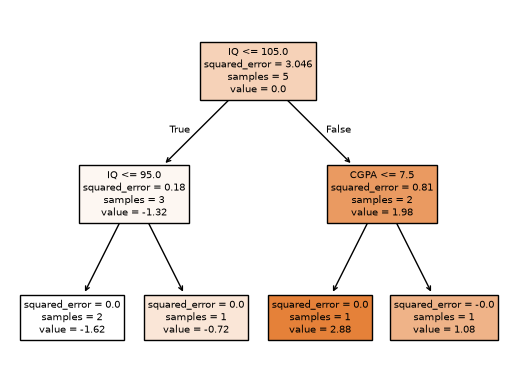

In [103]:
plot_tree(model_3,feature_names=['IQ','CGPA'], class_names=['Res3'], filled=True)


In [104]:
df['Pred4']=df['Pred1']+0.1*model_1.predict(X)+0.1*model_2.predict(X)+ 0.1*model_3.predict(X)

In [105]:
df

,IQ,CGPA,Salary,Pred1,Res1,Pred2,Res2,Pred3,Res3,Pred4
0,90,8,3,4.8,-1.8,4.62,-1.62,4.458,-1.62,4.296
1,100,7,4,4.8,-0.8,4.72,-0.72,4.648,-0.72,4.576
2,110,6,8,4.8,3.2,5.12,2.88,5.408,2.88,5.696
3,120,9,6,4.8,1.2,4.92,1.08,5.028,1.08,5.136
4,80,5,3,4.8,-1.8,4.62,-1.62,4.458,-1.62,4.296


In [106]:
df['Res4']=df['Salary']-df['Pred3']     # Y_pred= m0+ lr*m1+ lr*m2

In [107]:
df

,IQ,CGPA,Salary,Pred1,Res1,Pred2,Res2,Pred3,Res3,Pred4,Res4
0,90,8,3,4.8,-1.8,4.62,-1.62,4.458,-1.62,4.296,-1.458
1,100,7,4,4.8,-0.8,4.72,-0.72,4.648,-0.72,4.576,-0.648
2,110,6,8,4.8,3.2,5.12,2.88,5.408,2.88,5.696,2.592
3,120,9,6,4.8,1.2,4.92,1.08,5.028,1.08,5.136,0.972
4,80,5,3,4.8,-1.8,4.62,-1.62,4.458,-1.62,4.296,-1.458


# Classification

In [151]:
df= pd.read_csv('GB_Classification.csv')

In [152]:
df

,IQ,CGPA,Places
0,90,8,0
1,100,7,1
2,110,6,1
3,120,9,1
4,80,5,0
5,125,8,1
6,110,5,0


In [153]:
zeros=(df['Places']==0).sum()
ones=(df['Places']==1).sum()
df['Pred_log_odds']=log_odds=math.log(ones/zeros)
df['Pred1_Prob']=1/(1+np.exp(-df['Pred_log_odds']))
df['Res1']=df['Places']-df['Pred1_Prob']
df


,IQ,CGPA,Places,Pred_log_odds,Pred1_Prob,Res1
0,90,8,0,0.287682,0.571429,-0.571429
1,100,7,1,0.287682,0.571429,0.428571
2,110,6,1,0.287682,0.571429,0.428571
3,120,9,1,0.287682,0.571429,0.428571
4,80,5,0,0.287682,0.571429,-0.571429
5,125,8,1,0.287682,0.571429,0.428571
6,110,5,0,0.287682,0.571429,-0.571429


Training decision tree with X='IQ' and 'CGPA' and y ='Res1'

In [154]:
X=df[['IQ','CGPA']]
y=df['Res1']
DT1=DecisionTreeRegressor()
DT1.fit(X,y)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.4, 0.8333333333333334, 'IQ <= 95.0\nsquared_error = 0.245\nsamples = 7\nvalue = 0.0'),
 Text(0.2, 0.5, 'squared_error = 0.0\nsamples = 2\nvalue = -0.571'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'CGPA <= 5.5\nsquared_error = 0.16\nsamples = 5\nvalue = 0.229'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = -0.571'),
 Text(0.8, 0.16666666666666666, 'squared_error = 0.0\nsamples = 4\nvalue = 0.429')]

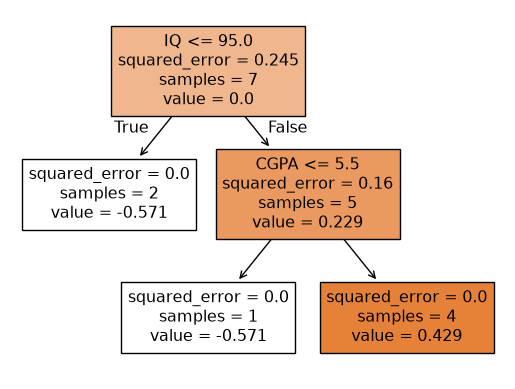

In [155]:
plot_tree(DT1,feature_names=['IQ','CGPA'],class_names=['Res1'],filled=True)

In [156]:
# 1. Determine which leaf node ID each row falls into
df['Leaf_ID'] = DT1.apply(X)

# 2. Calculate the components of your formula per row
df['Numerator'] = df['Res1']
df['Denominator'] = df['Pred1_Prob'] * (1 - df['Pred1_Prob'])

# 3. Sum these components up for each unique leaf node group
leaf_sums = df.groupby('Leaf_ID')[['Numerator', 'Denominator']].sum()

# 4. Apply your formula to find the transformed log-odds value for each leaf
leaf_sums['Transformed_Log_Odds_Update'] = leaf_sums['Numerator'] / leaf_sums['Denominator']

# 5. Map these optimal leaf updates back onto your original dataframe rows
df['Tree1_Log_Odds_Update'] = df['Leaf_ID'].map(leaf_sums['Transformed_Log_Odds_Update'])

# 6. Finally, update your Log-Odds and find the clean, stable Pred2_Prob!
learning_rate = 0.3  # It's standard practice to scale updates by a learning rate
df['Pred2_log_odds'] = df['Pred_log_odds'] + (learning_rate * df['Tree1_Log_Odds_Update'])
df['Pred2_Prob'] = 1 / (1 + np.exp(-df['Pred2_log_odds']))

# Drop temporary columns to keep it clean
df.drop(columns=['Leaf_ID', 'Numerator', 'Denominator', 'Tree1_Log_Odds_Update'], inplace=True)

In [157]:
df['Res2']=df['Places']-df['Pred2_Prob']
df

,IQ,CGPA,Places,Pred_log_odds,Pred1_Prob,Res1,Pred2_log_odds,Pred2_Prob,Res2
0,90,8,0,0.287682,0.571429,-0.571429,-0.412318,0.398356,-0.398356
1,100,7,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319
2,110,6,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319
3,120,9,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319
4,80,5,0,0.287682,0.571429,-0.571429,-0.412318,0.398356,-0.398356
5,125,8,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319
6,110,5,0,0.287682,0.571429,-0.571429,-0.412318,0.398356,-0.398356


In [158]:
X=df[['IQ','CGPA']]
y=df['Res2']
DT2=DecisionTreeRegressor()
DT2.fit(X,y)


,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max

[Text(0.4, 0.8333333333333334, 'IQ <= 95.0\nsquared_error = 0.122\nsamples = 7\nvalue = 0.005'),
 Text(0.2, 0.5, 'squared_error = 0.0\nsamples = 2\nvalue = -0.398'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'CGPA <= 5.5\nsquared_error = 0.08\nsamples = 5\nvalue = 0.166'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'squared_error = 0.0\nsamples = 1\nvalue = -0.398'),
 Text(0.8, 0.16666666666666666, 'squared_error = 0.0\nsamples = 4\nvalue = 0.307')]

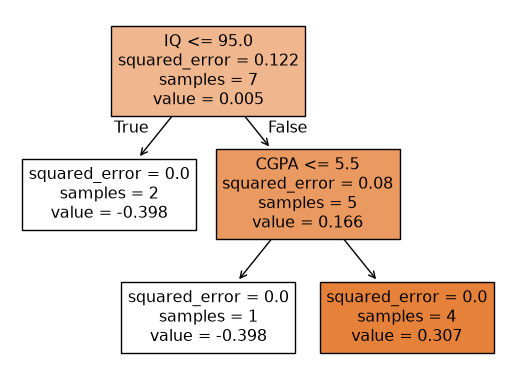

In [159]:
plot_tree(DT2,feature_names=['IQ','CGPA'],class_names=['Res2'],filled=True)

In [160]:
# 1. Determine which leaf node ID each row falls into
df['Leaf_ID'] = DT2.apply(X)

# 2. Calculate the components of your formula per row
df['Numerator'] = df['Res2']
df['Denominator'] = df['Pred2_Prob'] * (1 - df['Pred2_Prob'])

# 3. Sum these components up for each unique leaf node group
leaf_sums = df.groupby('Leaf_ID')[['Numerator', 'Denominator']].sum()

# 4. Apply your formula to find the transformed log-odds value for each leaf
leaf_sums['Transformed_Log_Odds_Update'] = leaf_sums['Numerator'] / leaf_sums['Denominator']

# 5. Map these optimal leaf updates back onto your original dataframe rows
df['Tree1_Log_Odds_Update'] = df['Leaf_ID'].map(leaf_sums['Transformed_Log_Odds_Update'])

# 6. Finally, update your Log-Odds and find the clean, stable Pred2_Prob!
learning_rate = 0.5  # It's standard practice to scale updates by a learning rate
df['Pred3_log_odds'] = df['Pred_log_odds'] + (learning_rate * df['Pred2_log_odds'])+(learning_rate * df['Tree1_Log_Odds_Update'])
df['Pred3_Prob'] = 1 / (1 + np.exp(-df['Pred3_log_odds']))

# Drop temporary columns to keep it clean
df.drop(columns=['Leaf_ID', 'Numerator', 'Denominator', 'Tree1_Log_Odds_Update'], inplace=True)

In [161]:
df['Res3']=df['Places']-df['Pred3_Prob']
df

,IQ,CGPA,Places,Pred_log_odds,Pred1_Prob,Res1,Pred2_log_odds,Pred2_Prob,Res2,Pred3_log_odds,Pred3_Prob,Res3
0,90,8,0,0.287682,0.571429,-0.571429,-0.412318,0.398356,-0.398356,-0.749534,0.320923,-0.320923
1,100,7,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319,1.415856,0.804688,0.195312
2,110,6,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319,1.415856,0.804688,0.195312
3,120,9,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319,1.415856,0.804688,0.195312
4,80,5,0,0.287682,0.571429,-0.571429,-0.412318,0.398356,-0.398356,-0.749534,0.320923,-0.320923
5,125,8,1,0.287682,0.571429,0.428571,0.812682,0.692681,0.307319,1.415856,0.804688,0.195312
6,110,5,0,0.287682,0.571429,-0.571429,-0.412318,0.398356,-0.398356,-0.749534,0.320923,-0.320923
